# Task 4. Detection of anomalies (single-class classification)

In [92]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from scipy.stats import entropy, gmean, kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score




## 1. Loading the files and creating a data frame

In [94]:
# - Durchsucht Unterordner Z01 und Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks


440 files 
 Seminaraufgabe_2_Datei\sig\Z03\Z03_Pos06_RC2_75k_0000\Z03_Pos06_RC2_75k_0000_1307031507\Wav\Z03_Pos06_RC2_75k_0000_1307031507_00000_14_Ch1.wav


In [95]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)

# Zeigt die ersten 5 Einträge zur Qualitätskontrolle (Error-Checking)
print("DataFrame-Übersicht:")
print(df.head())

DataFrame-Übersicht:
                                                  fn  \
0  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...   
1  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...   
2  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...   
3  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...   
4  Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...   

                                                 sig spec   mID        time  \
0  [0.00048828125, 0.00244140625, 0.0029296875, 0...  Z01  0000  1307031427   
1  [0.001953125, 0.0, 0.00146484375, 0.001953125,...  Z01  0000  1307031427   
2  [0.00146484375, 0.0, 0.00048828125, 0.00195312...  Z01  0000  1307031427   
3  [-0.00048828125, 0.0009765625, 0.0, -0.0009765...  Z01  0000  1307031427   
4  [0.00048828125, 0.00146484375, 0.00048828125, ...  Z01  0001  1312091511   

     rID  sID  stft  
0  00000  Ch1  None  
1  00000  Ch2  None  
2  00001  Ch1  None  
3  00001  Ch2  None  
4  00000  Ch1  None  


## 2. Applying STFT

In [96]:
for idx, row in df.iterrows():
    fs = 1e6  # Anpassen an reale Abtastrate
    f, t, Zxx = stft(row['sig'], 
                    fs=fs,
                    window='hann', 
                    nperseg=512,    # Fensterlänge
                    noverlap=256)   # 50% Overlap
    
    df.at[idx, 'stft'] = (f, t, np.abs(Zxx))

In [97]:
def plot_spectrogram_signal(row, nfft=2048, noverlap=1024, fmax=100000):
    signal = row['sig']

    # Setzt die Abtastrate (Samplingrate); falls nicht im DataFrame, Standardwert verwenden
    fs = row.get('fs', 1041666)  # ggf. anpassen!

    # Erstellt eine neue Abbildung für das Spektrogramm
    plt.figure(figsize=(10, 5))

    # Berechnet und plottet das Spektrogramm des Signals:
    
    Pxx, freqs, bins, im = plt.specgram(
        signal,                 # Zeitsignal
        NFFT=nfft,              # Fensterlänge für die FFT (hier 2048 Samples)
        Fs=fs,                  # Abtastrate in Hz
        noverlap=noverlap,      # Überlappung zwischen den Fenstern (hier 1024 Samples)
        scale='dB',             # Amplituden werden in Dezibel dargestellt
        cmap='magma'          # Farbskala für die Darstellung (gelb, grün, türkis)
    )

    plt.title(f"Spektrogramm {row['spec']} - {row['sID']}")     # Titel 
    plt.ylabel('Frequenz [Hz]')                                 # y-Achse
    plt.xlabel('Zeit [s]')                                      # x-Achse
    plt.ylim(0, fmax)                                           # Relevanten Bereich zeigen (100 kHz)

    # Fügt eine Farbskala hinzu, die die Amplitude in dB anzeigt
    plt.colorbar(label='Amplitude [dB]')
    
    plt.tight_layout()
    plt.show()

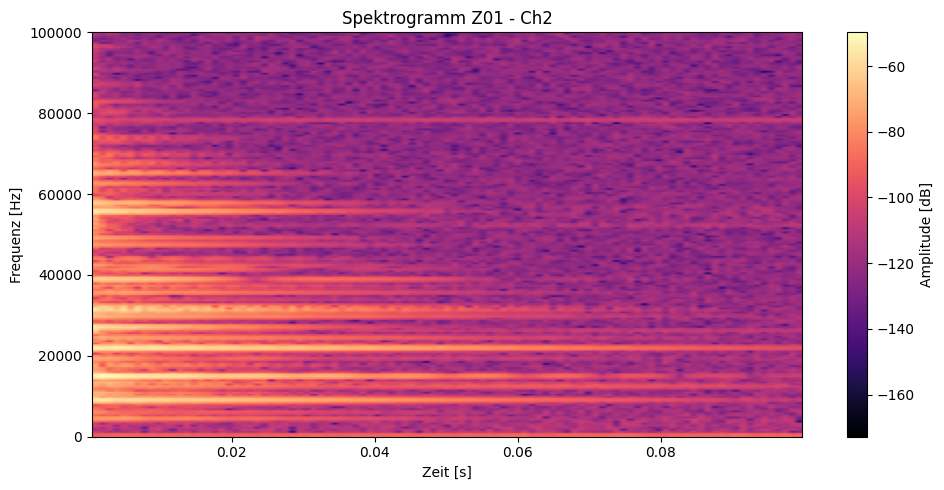

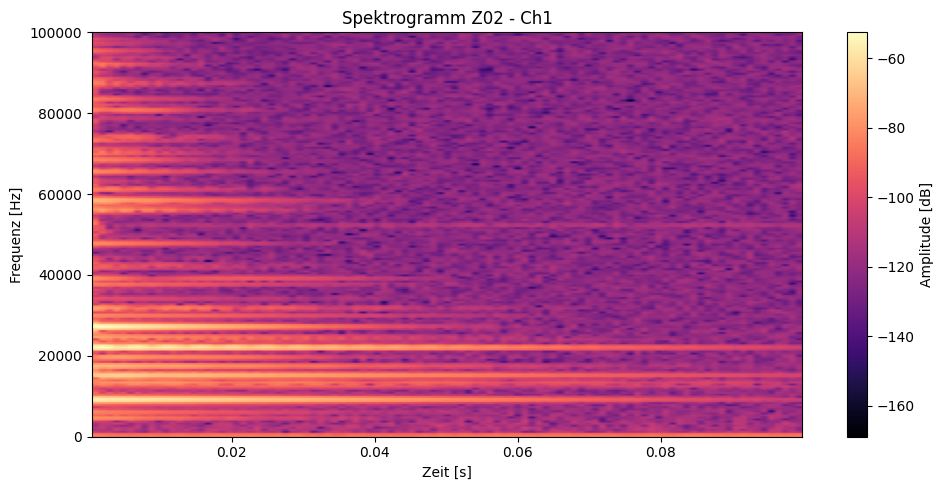

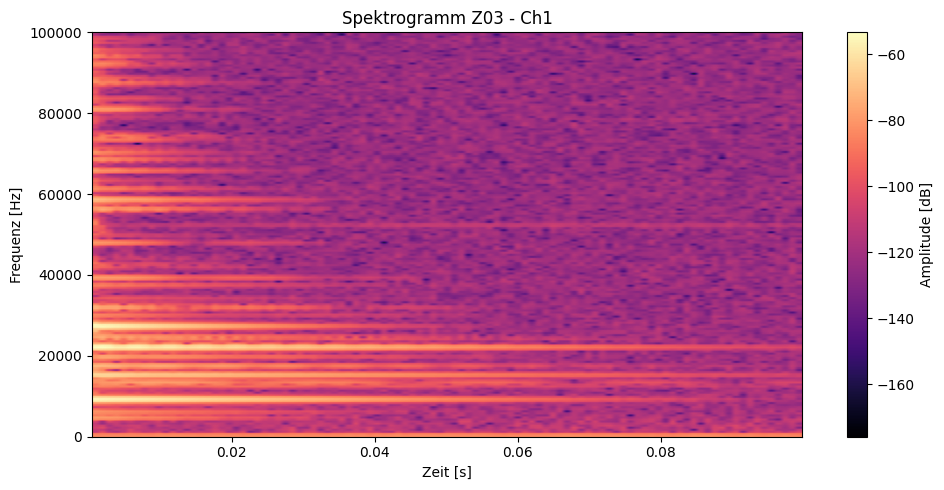

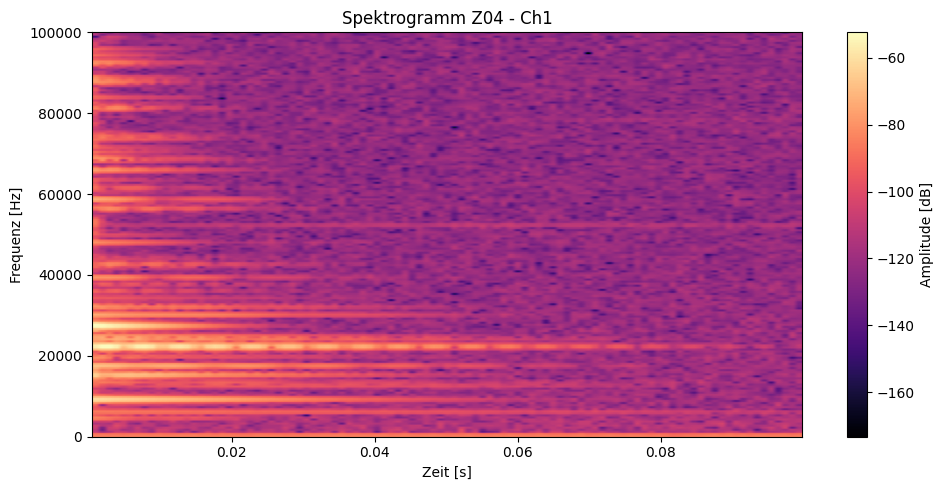

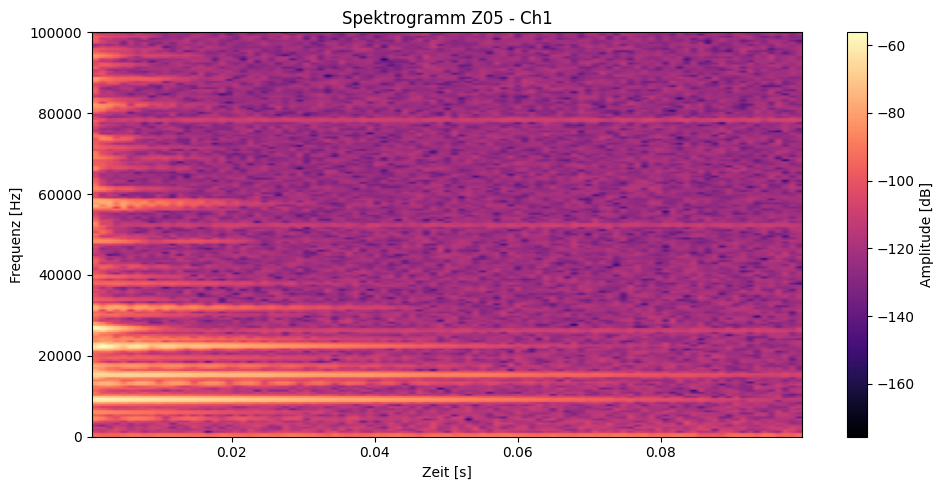

In [98]:
sampleset=[1, 228, 254, 370, 420]
for i in sampleset:
    plot_spectrogram_signal(df.iloc[i])

## 3. Feature extraction

In [99]:
def analyze_stft(stft):
    magnitude = np.abs(stft[2])
    mag_mean = np.mean(magnitude, axis=1)  # magnitude averaged by time
    spectral_mean = np.sum(stft[0] * mag_mean) / np.sum(mag_mean) # average frequency, weighted by magnitude
    spectral_variance = np.sum(((stft[0] - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean) #distance of each frequency bin from the mean
    upper_half = mag_mean[len(stft[0])//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist) # how irregular the upper part of the spectrum is
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half) # how much noise there is
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = stft[0][rolloff_idx]  # 85% of energy is below this frequency
    kurt_upper = kurtosis(upper_half) # reflects spikiness or asymmetry in the upper band
    
    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper


def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)  # fourth moment
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))  # peak amplitude
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis



In [100]:
featureslist = [
    'sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis',
    'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis'
]
# for i in featureslist:
#     df[i] = None

In [101]:
for idx, row in df.iterrows():
    sig = row['sig']
    sig_mean, sig_var, sig_skew, sig_rms, sig_peak, sig_kurtosis = analyze_signal(sig)
    df.at[idx, 'sig_mean'] = sig_mean
    df.at[idx, 'sig_var'] = sig_var
    df.at[idx, 'sig_skew'] = sig_skew
    df.at[idx, 'sig_rms'] = sig_rms
    df.at[idx, 'sig_peak'] = sig_peak
    df.at[idx, 'sig_kurtosis'] = sig_kurtosis
    
    stft = row['stft']
    spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper = analyze_stft(stft)
    df.at[idx, 'spec_mean'] = spectral_mean
    df.at[idx, 'spec_var'] = spectral_variance
    df.at[idx, 'spec_entropy_up'] = entropy_upper
    df.at[idx, 'spec_flatness'] = flatness
    df.at[idx, 'spec_rolloff_freq'] = rolloff_freq
    df.at[idx, 'spec_kurtosis'] = kurt_upper


    

In [102]:
# Ensure all feature columns are numeric in original df before splitting
for feature in featureslist:
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

df.head(3)



,fn,sig,spec,mID,time,rID,sID,stft,sig_mean,sig_var,sig_skew,sig_rms,sig_peak,sig_kurtosis,spec_mean,spec_var,spec_entropy_up,spec_flatness,spec_rolloff_freq,spec_kurtosis
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",Z01,0000,1307031427,00000,Ch1,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.001518,0.000824,-0.020609,0.028749,0.272095,16.887122,55102.270438,9.724635e+09,4.668870,0.870555,76171.875,27.552674
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",Z01,0000,1307031427,00000,Ch2,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.001020,0.001568,-0.173273,0.039612,0.457214,16.392937,51765.810211,8.161864e+09,4.562784,0.817427,54687.500,37.586437
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",Z01,0000,1307031427,00001,Ch1,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.001247,0.000837,0.003026,0.028963,0.274536,16.867039,51583.906401,8.757124e+09,4.692256,0.900276,64453.125,45.445533


## Separate 2 Channels

In [103]:

df['sID'] = df['sID'].astype(str).str.strip()


df_ch1 = df[df['sID'] == 'Ch1'].copy()
df_ch2 = df[df['sID'] == 'Ch2'].copy()

df_ch1.info() 
df_ch2.info()



print(f"Anzahl der Beispiele in Kanal 1 (Ch1): {df_ch1.shape[0]}")
print(f"Anzahl der Beispiele in Kanal 2 (Ch2): {df_ch2.shape[0]}")

print("\nVerteilung der Spezifikation (spec) in Ch1:")
print(df_ch1['spec'].value_counts())

print("\nVerteilung der Spezifikation (spec) in Ch2:")
print(df_ch2['spec'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 0 to 438
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fn                 220 non-null    object 
 1   sig                220 non-null    object 
 2   spec               220 non-null    object 
 3   mID                220 non-null    object 
 4   time               220 non-null    object 
 5   rID                220 non-null    object 
 6   sID                220 non-null    object 
 7   stft               220 non-null    object 
 8   sig_mean           220 non-null    float64
 9   sig_var            220 non-null    float64
 10  sig_skew           220 non-null    float64
 11  sig_rms            220 non-null    float64
 12  sig_peak           220 non-null    float64
 13  sig_kurtosis       220 non-null    float64
 14  spec_mean          220 non-null    float64
 15  spec_var           220 non-null    float64
 16  spec_entropy_up    220 non-null

## Leave P Group(s) Out cross-validation strategy - **1st Channel**

In [104]:
# First: assign label = 1 for all normal (Z01–Z04), and 0 for anomalies (Z05)
df_ch1['label'] = df_ch1['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Define a function to filter dataset by group membership
def filter_groups(df, train_groups, test_groups):
    train = df[df['spec'].isin(train_groups)].copy()
    test  = df[df['spec'].isin(test_groups)].copy()
    return train.reset_index(drop=True), test.reset_index(drop=True)

# Create splits as defined
splits = [
    (['Z01', 'Z02', 'Z03'], ['Z04', 'Z05']),
    (['Z01', 'Z02', 'Z04'], ['Z03', 'Z05']),
    (['Z01', 'Z03', 'Z04'], ['Z02', 'Z05']),
    (['Z02', 'Z03', 'Z04'], ['Z01', 'Z05']),
]

group_splits_ch1 = []

# Process each split
# labels: first element in array - amount of Z05 data, second element - amount of Z01-Z04
for idx, (train_groups, test_groups) in enumerate(splits, 1):
    train_df, test_df = filter_groups(df_ch1, train_groups, test_groups)

    print(f"\nSplit {idx} (Ch1)")
    print(f"Train groups: {train_groups}")
    print(f"Test groups: {test_groups}")
    print(f"Train size: {train_df.shape[0]} (labels: {np.bincount(train_df['label'])})")
    print(f"Test  size: {test_df.shape[0]} (labels: {np.bincount(test_df['label'])})")

    group_splits_ch1.append((train_df, test_df))

print(group_splits_ch1)



Split 1 (Ch1)
Train groups: ['Z01', 'Z02', 'Z03']
Test groups: ['Z04', 'Z05']
Train size: 140 (labels: [  0 140])
Test  size: 80 (labels: [20 60])

Split 2 (Ch1)
Train groups: ['Z01', 'Z02', 'Z04']
Test groups: ['Z03', 'Z05']
Train size: 180 (labels: [  0 180])
Test  size: 40 (labels: [20 20])

Split 3 (Ch1)
Train groups: ['Z01', 'Z03', 'Z04']
Test groups: ['Z02', 'Z05']
Train size: 180 (labels: [  0 180])
Test  size: 40 (labels: [20 20])

Split 4 (Ch1)
Train groups: ['Z02', 'Z03', 'Z04']
Test groups: ['Z01', 'Z05']
Train size: 100 (labels: [  0 100])
Test  size: 120 (labels: [ 20 100])
[(                                                    fn  \
0    Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...   
1    Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...   
2    Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...   
3    Z01_Pos00_RC2_75k_0001_1312091511_00001_14_Ch1...   
4    Z01_Pos00_RC2_75k_0002_1312101402_00000_14_Ch1...   
..                                                 ... 

## Leave P Group(s) Out cross-validation strategy - **2nd Channel**

In [105]:
# First: assign label = 1 for all normal (Z01–Z04), and 0 for anomalies (Z05)
df_ch2['label'] = df_ch2['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Define a function to filter dataset by group membership
def filter_groups(df, train_groups, test_groups):
    train = df[df['spec'].isin(train_groups)].copy()
    test  = df[df['spec'].isin(test_groups)].copy()
    return train.reset_index(drop=True), test.reset_index(drop=True)

# Create splits as defined
splits = [
    (['Z01', 'Z02', 'Z03'], ['Z04', 'Z05']),
    (['Z01', 'Z02', 'Z04'], ['Z03', 'Z05']),
    (['Z01', 'Z03', 'Z04'], ['Z02', 'Z05']),
    (['Z02', 'Z03', 'Z04'], ['Z01', 'Z05']),
]

group_splits_ch2 = []

# Process each split
# labels: first element in array - amount of Z05 data, second element - amount of Z01-Z04
for idx, (train_groups, test_groups) in enumerate(splits, 1):
    train_df, test_df = filter_groups(df_ch2, train_groups, test_groups)

    print(f"\nSplit {idx} (Ch2)")
    print(f"Train groups: {train_groups}")
    print(f"Test groups: {test_groups}")
    print(f"Train size: {train_df.shape[0]} (labels: {np.bincount(train_df['label'])})")
    print(f"Test  size: {test_df.shape[0]} (labels: {np.bincount(test_df['label'])})")

    group_splits_ch2.append((train_df, test_df))


Split 1 (Ch2)
Train groups: ['Z01', 'Z02', 'Z03']
Test groups: ['Z04', 'Z05']
Train size: 140 (labels: [  0 140])
Test  size: 80 (labels: [20 60])

Split 2 (Ch2)
Train groups: ['Z01', 'Z02', 'Z04']
Test groups: ['Z03', 'Z05']
Train size: 180 (labels: [  0 180])
Test  size: 40 (labels: [20 20])

Split 3 (Ch2)
Train groups: ['Z01', 'Z03', 'Z04']
Test groups: ['Z02', 'Z05']
Train size: 180 (labels: [  0 180])
Test  size: 40 (labels: [20 20])

Split 4 (Ch2)
Train groups: ['Z02', 'Z03', 'Z04']
Test groups: ['Z01', 'Z05']
Train size: 100 (labels: [  0 100])
Test  size: 120 (labels: [ 20 100])


## One-Class Classifier Training – Ch1

In [ ]:
print("One-Class SVM — Training on each split (Ch1)")

for idx, (train_df, test_df) in enumerate(group_splits_ch1, 1):
    print(f"\nSplit {idx}")

    X_train = train_df[train_df['label'] == 1][featureslist]
    X_test = test_df[featureslist].select_dtypes(include=[float, int])
    y_test = test_df['label']

    print(f"X_train shape: {X_train.shape}")
    print(f"X_train columns: {X_train.columns.tolist()}")
    print(X_train.head())

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    model.fit(X_train_scaled)

    y_pred = model.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == 1, 1, 0)

    print(classification_report(y_test, y_pred_binary, digits=3))

    conf = confusion_matrix(y_test, y_pred_binary)
    print("Confusion Matrix:\n", conf)

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_pred_binary)
        print(f"ROC-AUC Score: {auc:.3f}")
    else:
        print("ROC-AUC undefined (only one class present in y_test)")


One-Class SVM — Training on each split (Ch1)

Split 1
X_train shape: (140, 12)
X_train columns: ['sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis', 'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis']
   sig_mean   sig_var  sig_skew   sig_rms  sig_peak  sig_kurtosis  \
0  0.001518  0.000824 -0.020609  0.028749  0.272095     16.887122   
1  0.001247  0.000837  0.003026  0.028963  0.274536     16.867039   
2  0.000970  0.000561  0.035185  0.023708  0.245697     16.344766   
3  0.000843  0.000567  0.026321  0.023826  0.244232     16.194716   
4  0.000748  0.000657 -0.003974  0.025645  0.254486     15.596158   

      spec_mean      spec_var  spec_entropy_up  spec_flatness  \
0  55102.270438  9.724635e+09         4.668870       0.870555   
1  51583.906401  8.757124e+09         4.692256       0.900276   
2  56069.208560  9.647947e+09         4.675142       0.905406   
3  55983.267477  9.596073e+09         4.675885       0.

## 4. Feature overview using Matplotlib

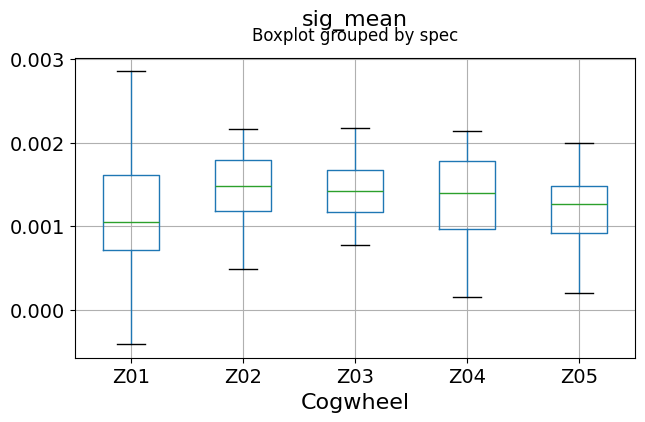

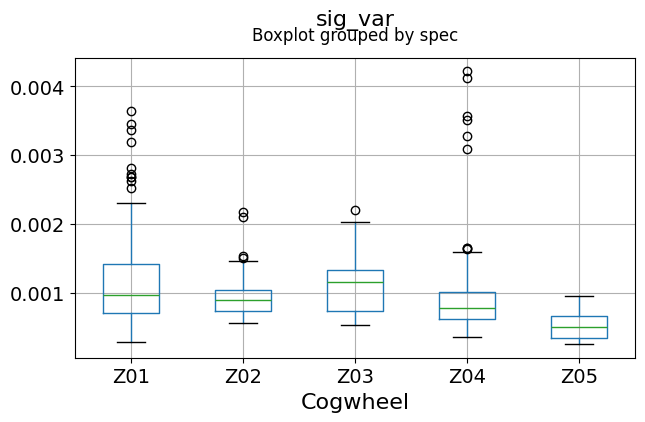

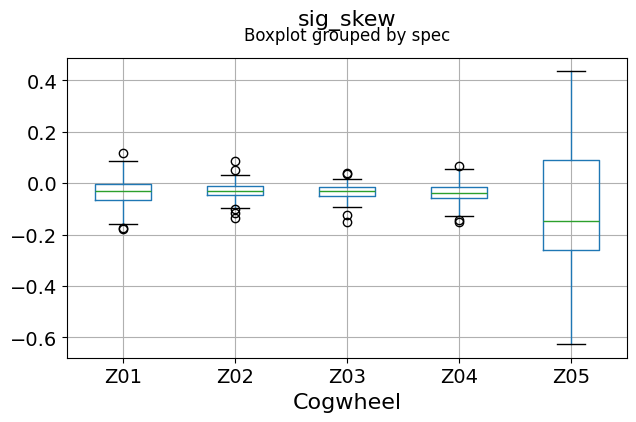

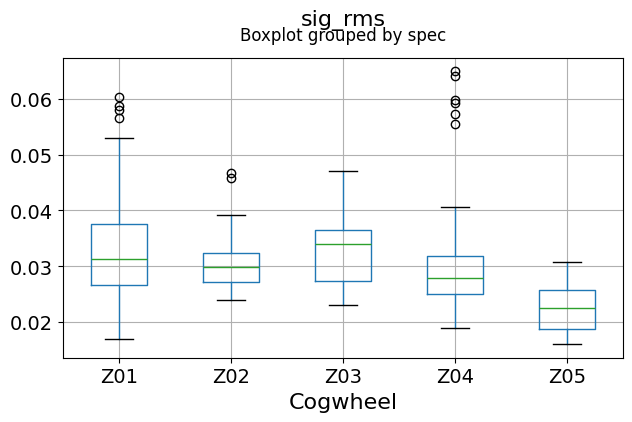

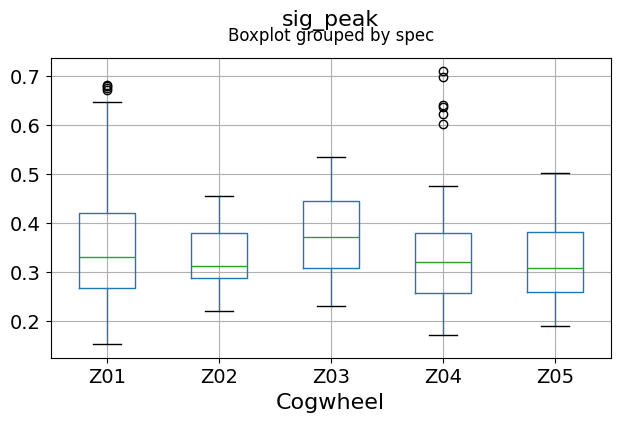

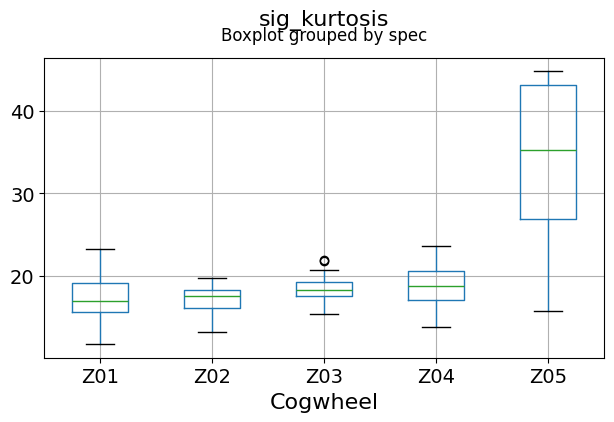

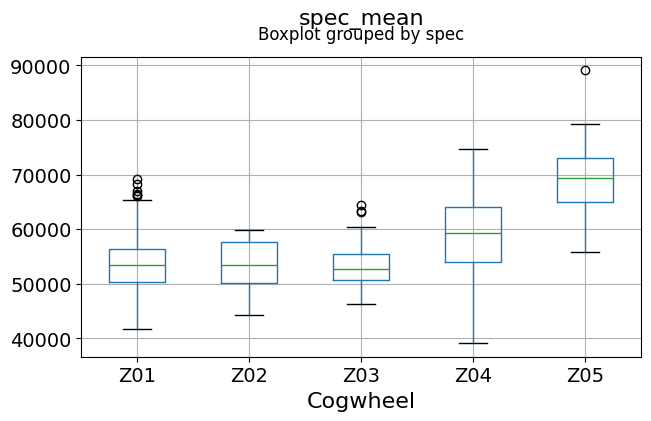

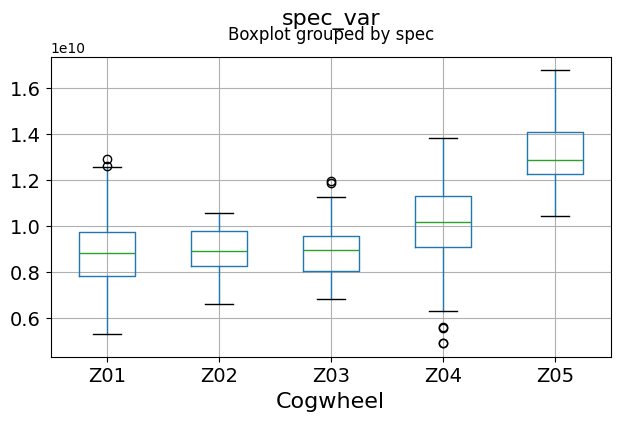

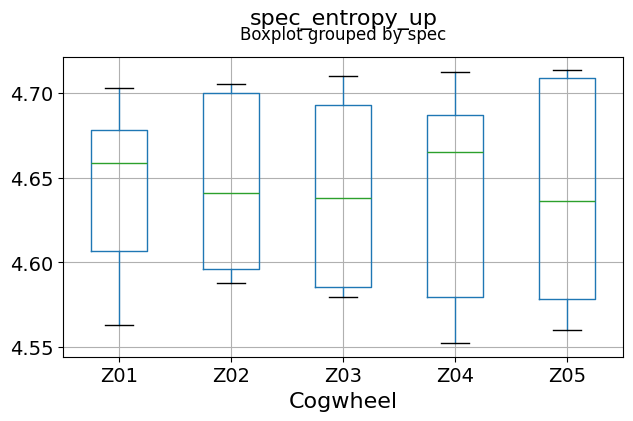

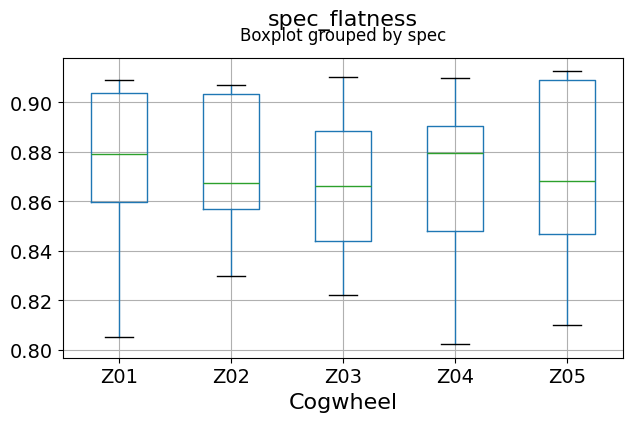

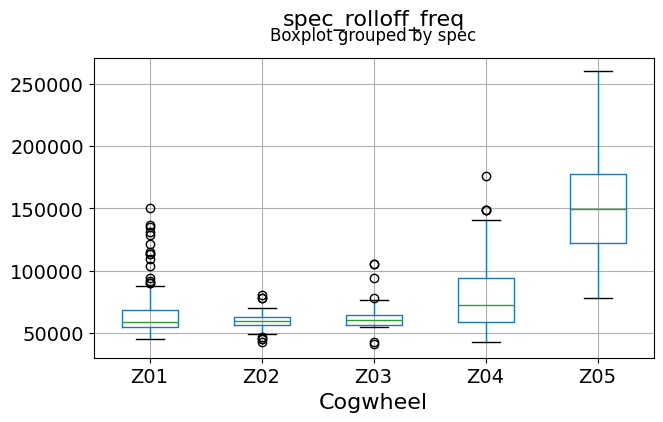

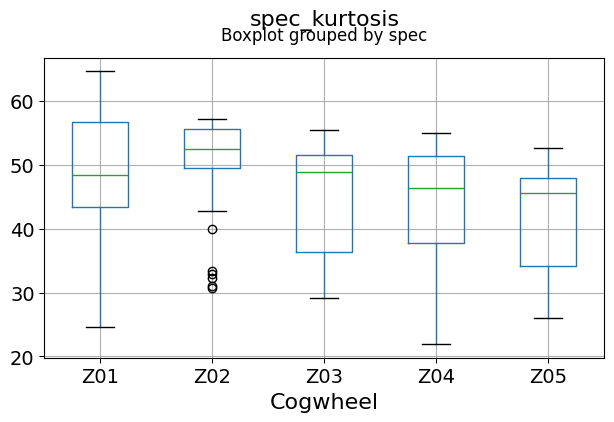

In [107]:
# boxplot by output labels (Z01-Z05)
for c in df.columns[8:]:
    df.boxplot(c,by='spec',figsize=(7,4),fontsize=14)
    plt.title("{}\n".format(c),fontsize=16)
    plt.xlabel("Cogwheel", fontsize=16)
    plt.show()


Text(0, 0.5, 'Rolloff Frequency')

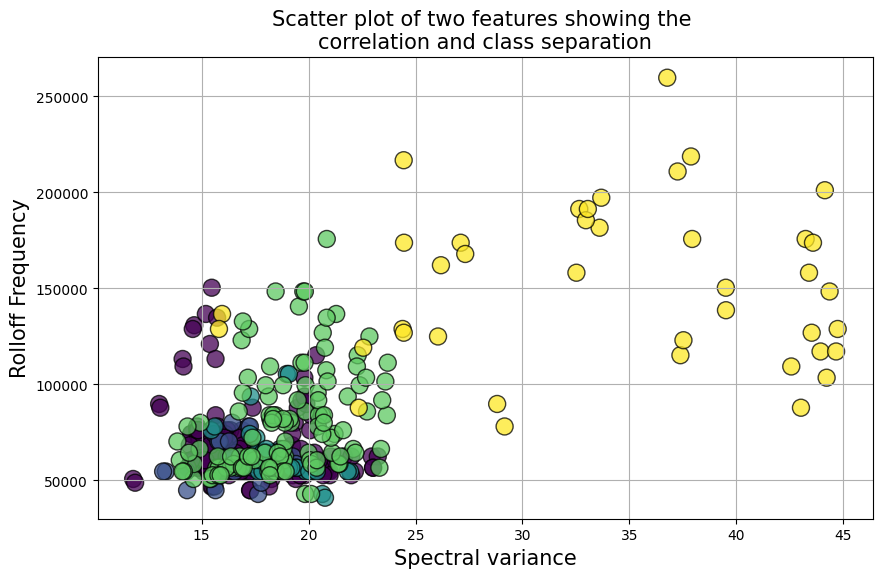

In [108]:
plt.figure(figsize=(10,6))
plt.scatter(df['sig_kurtosis'], df['spec_rolloff_freq'], c=df['spec'].apply(lambda x: int(x[-1])), edgecolors='k', alpha=0.75, s=150)
plt.grid(True)
plt.title("Scatter plot of two features showing the \ncorrelation and class separation",fontsize=15)
plt.xlabel("Spectral variance",fontsize=15)
plt.ylabel("Rolloff Frequency",fontsize=15)

C:\Users\OsenD\AppData\Local\Temp\ipykernel_19004\1607370228.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet', 30)
C:\Users\OsenD\AppData\Local\Temp\ipykernel_19004\1607370228.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels,fontsize=8)
C:\Users\OsenD\AppData\Local\Temp\ipykernel_19004\1607370228.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels,fontsize=8)


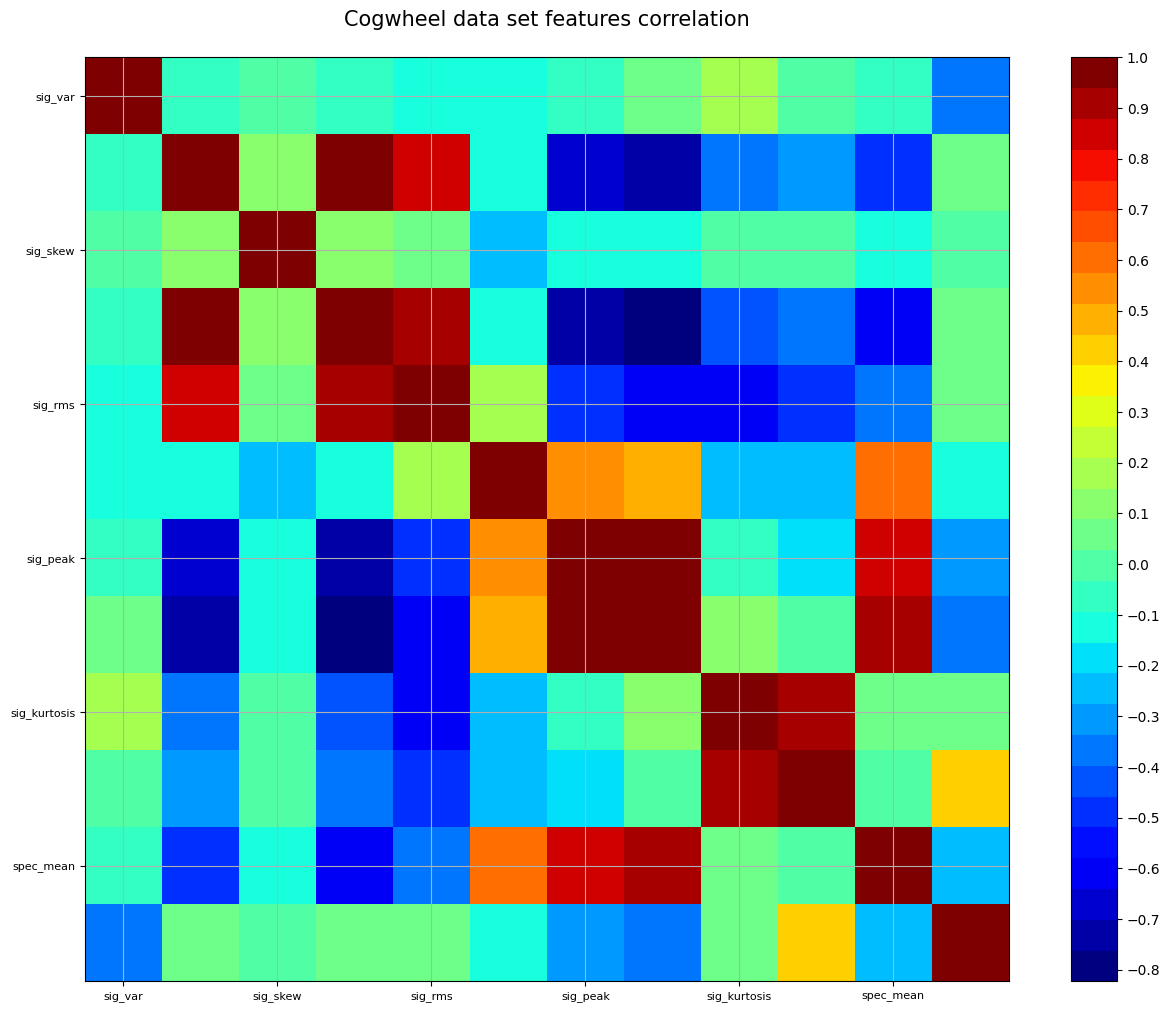

In [109]:
just_features = df[['sig_mean','sig_var','sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis', 
                    'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis']]

def correlation_matrix(df):

    fig = plt.figure(figsize=(16,12))
    ax1 = fig.add_subplot(111)
    cmap = cm.get_cmap('jet', 30)
    cax = ax1.imshow(df.corr(), interpolation="nearest", cmap=cmap)
    ax1.grid(True)
    plt.title('Cogwheel data set features correlation\n',fontsize=15)
    labels=df.columns
    ax1.set_xticklabels(labels,fontsize=8)
    ax1.set_yticklabels(labels,fontsize=8)
    # Add colorbar, make sure to specify tick locations to match desired ticklabels
    fig.colorbar(cax, ticks=[0.1*i for i in range(-11,11)])
    plt.show()

correlation_matrix(just_features)

## 5. Feature overview using Seaborn

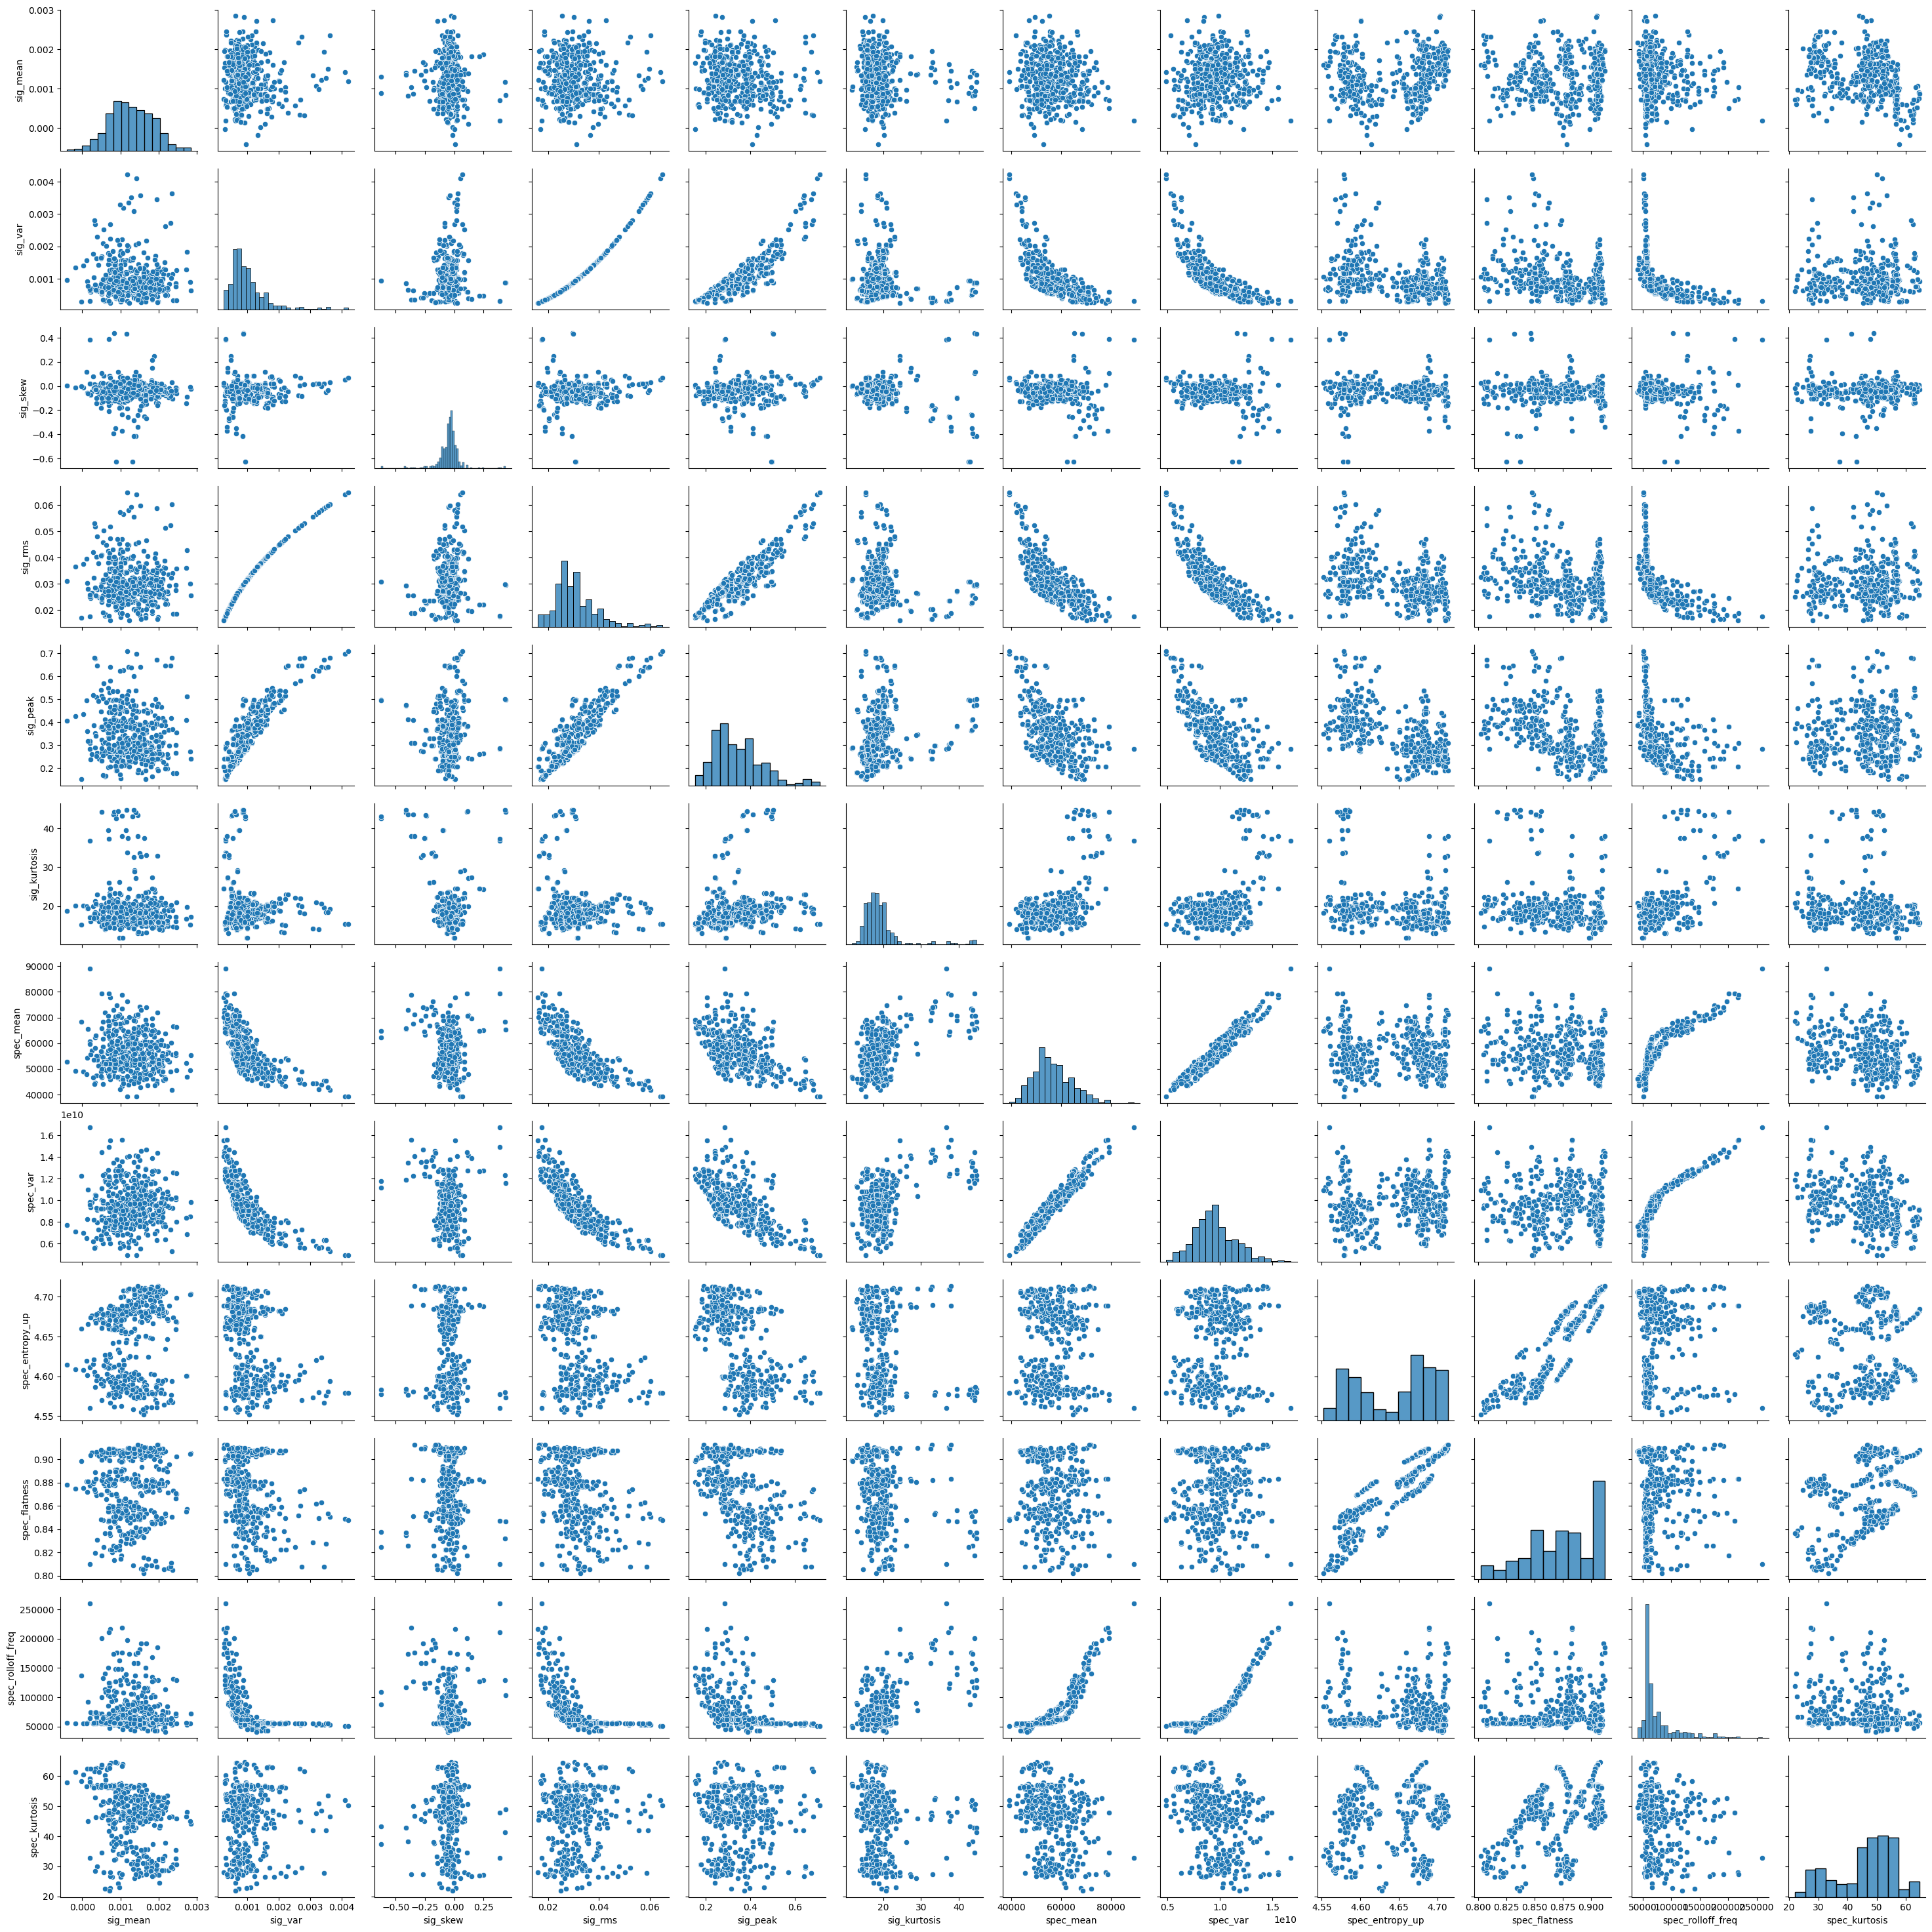

In [110]:
sns.pairplot(just_features)


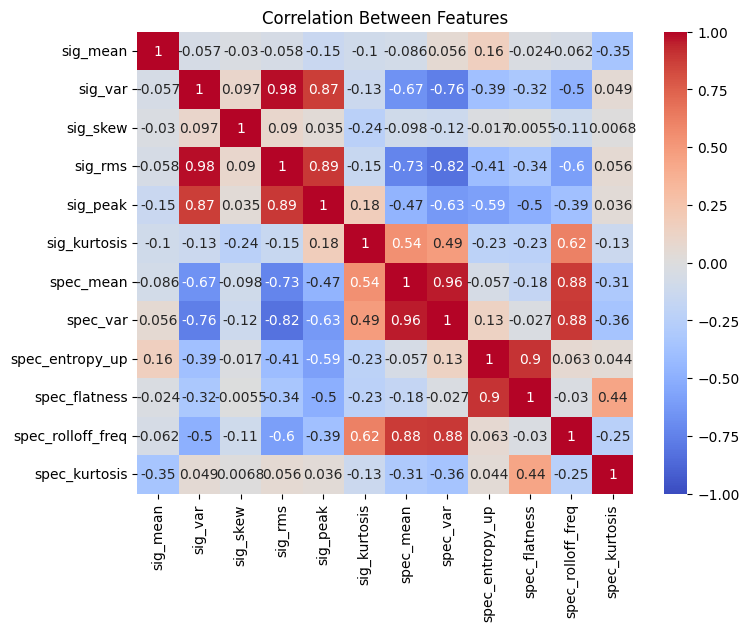

In [111]:
plt.figure(figsize=(8, 6))
sns.heatmap(just_features.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Features")
plt.show()


In [112]:
scaler = StandardScaler()
X = scaler.fit_transform(just_features)
dfx = pd.DataFrame(data=X, columns=just_features.columns)
dfx.head(10)

,sig_mean,sig_var,sig_skew,sig_rms,sig_peak,sig_kurtosis,spec_mean,spec_var,spec_entropy_up,spec_flatness,spec_rolloff_freq,spec_kurtosis
0,0.429673,-0.315921,0.235224,-0.249060,-0.668882,-0.439613,-0.171371,0.097818,0.516770,-0.098844,-0.002913,-1.831869
1,-0.470290,0.931505,-1.407277,1.079825,1.048509,-0.525613,-0.611364,-0.698580,-1.678182,-1.938559,-0.643835,-0.842724
2,-0.060710,-0.294010,0.489512,-0.222953,-0.646233,-0.443108,-0.635352,-0.395231,1.000638,0.930336,-0.352507,-0.067961
3,-0.980221,1.015069,-1.108481,1.155414,1.125517,-0.539042,-0.995562,-1.120084,-1.597349,-1.107612,-0.643835,0.171545
4,-0.560942,-0.757049,0.835503,-0.865690,-0.913779,-0.533996,-0.043857,0.058737,0.646530,1.107978,-0.002913,1.091604
5,-0.263008,0.233639,-0.894630,0.388271,0.500111,-0.160762,-0.797457,-1.051769,0.649201,1.075206,-0.643835,1.049803
6,-0.791310,-0.747250,0.740137,-0.851247,-0.927369,-0.560109,-0.055190,0.032302,0.661911,1.107799,-0.002913,1.033741
7,-0.519562,0.326532,-1.054846,0.486343,0.559282,-0.154850,-0.780767,-1.038106,0.836514,1.165470,-0.643835,0.944428
8,-0.962937,-0.596115,0.414201,-0.628759,-0.832241,-0.664272,-0.276383,-0.187231,0.795804,1.167567,-0.177710,1.799993
9,-1.649424,1.032570,-1.071670,1.170636,1.528960,0.192467,-1.204758,-1.537479,-1.011762,-0.142511,-0.643835,1.640510


In [113]:
dfx.describe()

,sig_mean,sig_var,sig_skew,sig_rms,sig_peak,sig_kurtosis,spec_mean,spec_var,spec_entropy_up,spec_flatness,spec_rolloff_freq,spec_kurtosis
count,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-2.906766e-16,-8.881784e-17,9.689219e-17,4.521636e-16,-1.897472e-16,9.689219e-17,-4.521636e-16,3.229740e-16,-7.303249e-15,2.890617e-15,3.229740e-17,4.844610e-17
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-3.055908e+00,-1.267244e+00,-6.282481e+00,-1.803196e+00,-1.783799e+00,-1.325653e+00,-2.280335e+00,-2.360868e+00,-1.894470e+00,-2.461108e+00,-1.051694e+00,-2.385989e+00
25%,-7.439609e-01,-6.071367e-01,-3.112963e-01,-6.439360e-01,-7.507032e-01,-5.474764e-01,-6.500573e-01,-6.951483e-01,-1.015464e+00,-7.467975e-01,-5.855694e-01,-6.886658e-01
50%,-2.997198e-02,-2.583698e-01,7.779711e-02,-1.755136e-01,-2.090991e-01,-2.139055e-01,-1.508068e-01,-1.026752e-01,3.536098e-01,1.555523e-01,-4.107725e-01,1.677854e-01
75%,7.102715e-01,3.260229e-01,3.674852e-01,4.854569e-01,5.615471e-01,1.229633e-01,5.779728e-01,5.406014e-01,8.308481e-01,1.033057e+00,1.718835e-01,7.171344e-01
max,2.839533e+00,5.371325e+00,5.137630e+00,4.178057e+00,3.387061e+00,4.407466e+00,4.311898e+00,3.675473e+00,1.439513e+00,1.355910e+00,5.474054e+00,1.820676e+00


## 6. PCA

In [114]:
pca = PCA(n_components=None)
dfx_pca = pca.fit(dfx)

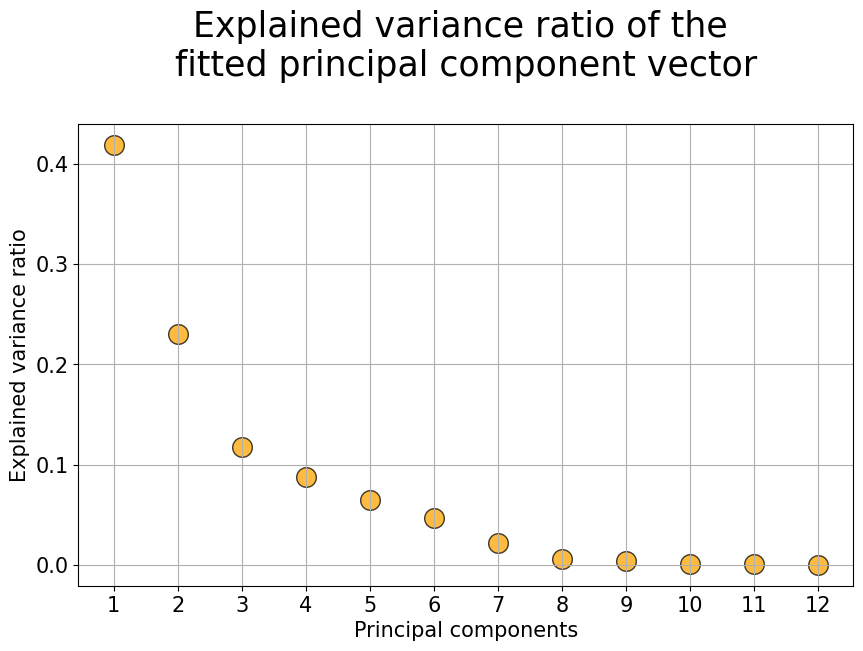

In [115]:
plt.figure(figsize=(10,6))
plt.scatter(x=[i+1 for i in range(len(dfx_pca.explained_variance_ratio_))],
            y=dfx_pca.explained_variance_ratio_,
           s=200, alpha=0.75,c='orange',edgecolor='k')
plt.grid(True)
plt.title("Explained variance ratio of the \nfitted principal component vector\n",fontsize=25)
plt.xlabel("Principal components",fontsize=15)
plt.xticks([i+1 for i in range(len(dfx_pca.explained_variance_ratio_))],fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Explained variance ratio",fontsize=15)
plt.show()

In [116]:
dfx_trans = pca.transform(dfx)
dfx_trans = pd.DataFrame(data=dfx_trans)
dfx_trans.head(10)

dfx_pca = pca.fit(dfx_trans)

## 7. Visualization

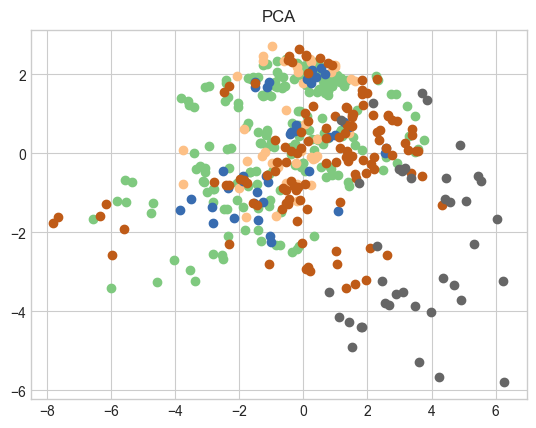

In [117]:
def do_plot(X_fit, title=None, labels=None):
    dimension = X_fit.shape[1]
    label_types = sorted(list(set(labels)))
    num_labels = len(label_types)
    colors = plt.cm.Accent(np.linspace(0, 1, num_labels))
    with plt.style.context(plt_style):
        fig = plt.figure()
        if dimension == 2:
            ax = fig.add_subplot(111)
            for lab, col in zip(label_types, colors):
                ax.scatter(X_fit[labels==lab, 0],
                           X_fit[labels==lab, 1],
                           color=col)
        elif dimension == 3:
            ax = fig.add_subplot(111, projection='3d')
            for lab, col in zip(label_types, colors):
                ax.scatter(X_fit[labels==lab, 0],
                           X_fit[labels==lab, 1],
                           X_fit[labels==lab, 2],
                           color=col)
        else:
            raise Exception('Unknown dimension: %d' % dimension)
        plt.title(title)
        plt.show()

plt_style = 'seaborn-v0_8-whitegrid'

do_plot(PCA(n_components=2).fit_transform(dfx), 'PCA', df['spec'].values)

c:\Users\OsenD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


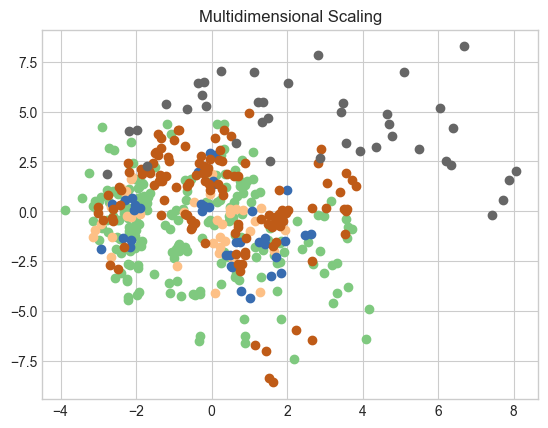

In [118]:
do_plot(MDS(n_components=2).fit_transform(dfx), 'Multidimensional Scaling',df['spec'].values)

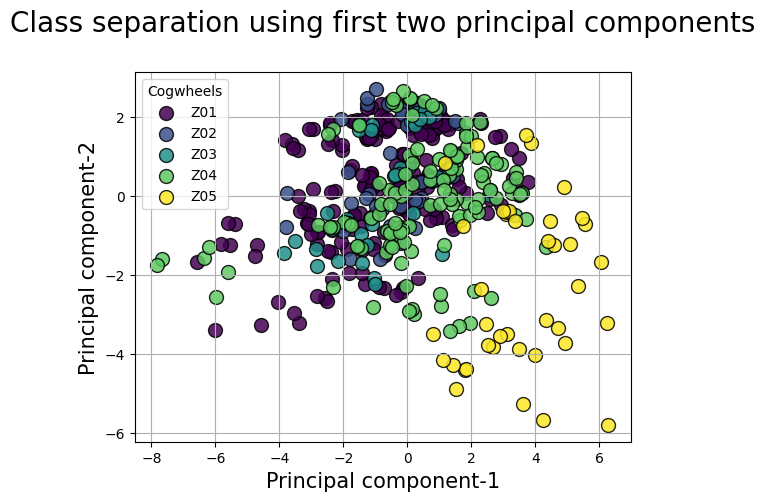

In [119]:
# Extract the class labels from the 'spec' column
class_labels = sorted(df['spec'].apply(lambda x: int(x[-1])).unique())

# Define a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(class_labels)))

# Plot each class separately
for label, color in zip(class_labels, colors):
    idx = df['spec'].apply(lambda x: int(x[-1])) == label
    plt.scatter(
        dfx_trans[0][idx],
        dfx_trans[1][idx],
        label=f"Z0{label}",
        edgecolors='k',
        alpha=0.85,
        s=100,
        color=color)

plt.grid(True)
plt.title("Class separation using first two principal components\n", fontsize=20)
plt.xlabel("Principal component-1", fontsize=15)
plt.ylabel("Principal component-2", fontsize=15)
plt.legend(title="Cogwheels")
plt.show()

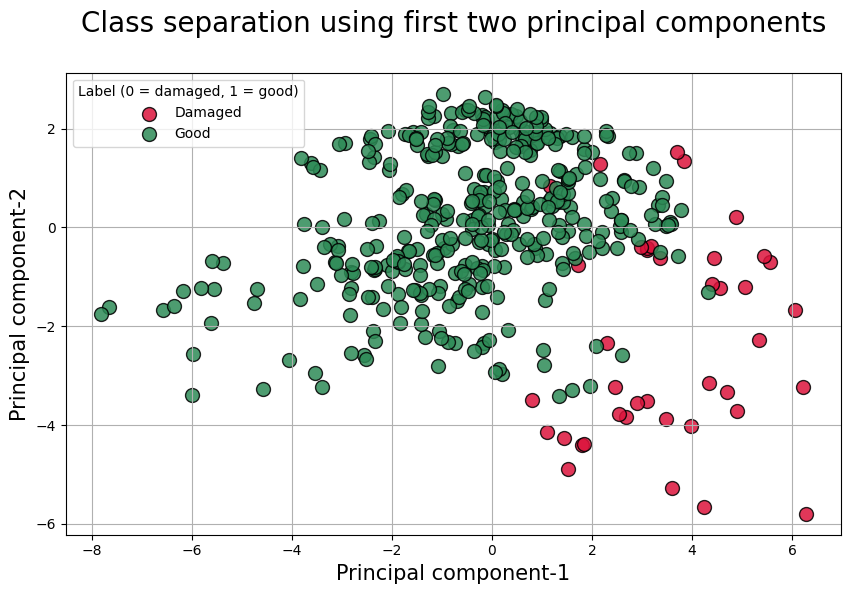

In [120]:
# Binary labels: 0 = damaged (Z05), 1 = good (Z01 to Z04)
binary_labels = df['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Set up colors and labels
colors = {0: 'crimson', 1: 'seagreen'}
label_names = {0: 'Damaged', 1: 'Good'}

plt.figure(figsize=(10, 6))

# Plot each binary class
for binary_class in [0, 1]:
    idx = binary_labels == binary_class
    plt.scatter(
        dfx_trans[0][idx],
        dfx_trans[1][idx],
        label=label_names[binary_class],
        color=colors[binary_class],
        edgecolors='k',
        alpha=0.85,
        s=100
    )

plt.grid(True)
plt.title("Class separation using first two principal components\n", fontsize=20)
plt.xlabel("Principal component-1", fontsize=15)
plt.ylabel("Principal component-2", fontsize=15)
plt.legend(title="Label (0 = damaged, 1 = good)")
plt.show()
